## 🎯  Introduction
This notebook presents a research-level pipeline for binary classification of MRI images (Yes vs. No).  
We leverage a **pre-trained ResNet18** backbone fine-tuned on the dataset, and analyze the model using **Grad-CAM++**, **SmoothGrad**, and detailed evaluation metrics.  

**Key Contributions:**
- Data augmentation and regularization to reduce overfitting  
- Training with early stopping and weight decay  
- Professional evaluation: Loss/Accuracy curves, Confusion Matrix, ROC/AUC, Probability Distribution  
- Interpretability using Grad-CAM++ and SmoothGrad over correct & failure cases

In [1]:
import os
import random
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import cv2
from PIL import Image

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Dataset Overview
The dataset contains MRI images divided into two classes:

- **Yes:** Positive MRI scans  
- **No:** Negative MRI scans  

We first perform exploratory data analysis (EDA) to understand **class distribution** and visualize **sample images** from each class.

In [2]:
data_dir = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"
yes_paths = sorted(glob(os.path.join(data_dir, "yes/*.*")))
no_paths = sorted(glob(os.path.join(data_dir, "no/*.*")))

all_paths = yes_paths + no_paths
labels = [1]*len(yes_paths) + [0]*len(no_paths)

df = pd.DataFrame({"path": all_paths, "label": labels})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(df.head())


                                                path  label
0  /kaggle/input/datasets/navoneel/brain-mri-imag...      0
1  /kaggle/input/datasets/navoneel/brain-mri-imag...      1
2  /kaggle/input/datasets/navoneel/brain-mri-imag...      1
3  /kaggle/input/datasets/navoneel/brain-mri-imag...      0
4  /kaggle/input/datasets/navoneel/brain-mri-imag...      1


## Data Augmentation
To improve generalization and reduce overfitting, we apply the following augmentations on training images:

- Random horizontal flips  
- Random rotations (±15°)  
- Color jitter (brightness & contrast)  
- Normalization to standard range [-1,1]

Validation images are only **resized and normalized** to preserve evaluation integrity.

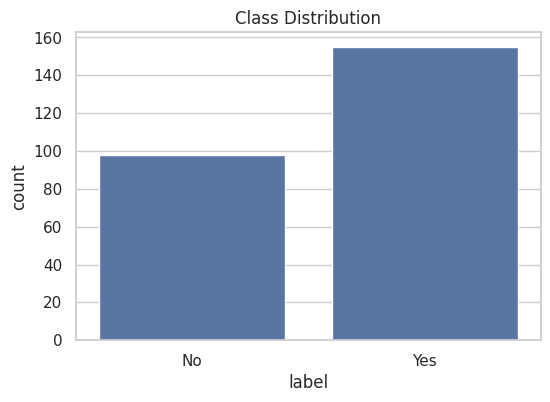

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.xticks([0,1], ["No","Yes"])
plt.title("Class Distribution")
plt.show()


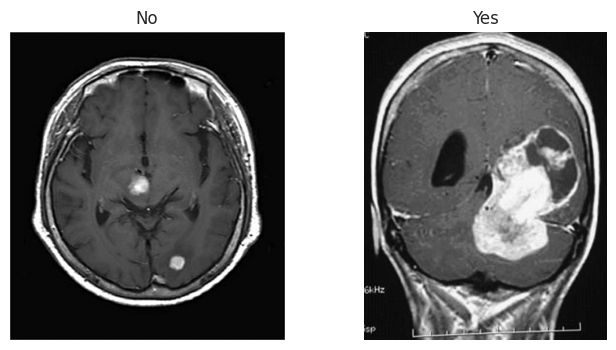

In [4]:
fig, axs = plt.subplots(1,2, figsize=(8,4))
for i, lbl in enumerate([0,1]):
    img = cv2.imread(df[df.label==lbl].iloc[0].path, cv2.IMREAD_GRAYSCALE)
    axs[i].imshow(img, cmap="gray")
    axs[i].axis("off")
    axs[i].set_title("Yes" if lbl==1 else "No")
plt.show()

## Model Architecture
We fine-tune a **ResNet18** pre-trained on ImageNet.  

- The final fully connected layer is replaced with a **single neuron output** for binary classification.  
- Loss function: `BCEWithLogitsLoss`  
- Optimizer: `Adam` with learning rate 1e-4 and weight decay 1e-4  

This setup allows the model to leverage **pretrained features** while adapting to MRI domain.

In [5]:
class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx].path
        label = self.df.iloc[idx].label
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

# Strong augmentations
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Split
train_df = df.sample(frac=0.8, random_state=SEED)
val_df = df.drop(train_df.index)

train_dataset = MRIDataset(train_df, transform=train_transform)
val_dataset = MRIDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

In [6]:
class MRIResNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        self.model.fc = nn.Linear(self.model.fc.in_features, 1)

    def forward(self, x):
        return self.model(x)

model = MRIResNet(pretrained=True).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


## Training Strategy
We train the model using the following strategies to improve performance:

- **Early Stopping**: Stops training when validation loss does not improve for 3 consecutive epochs  
- **Weight Decay**: Regularization to prevent overfitting  
- **Batch Size**: 16  
- **Epochs**: Up to 15  

The model performance is logged for **train & validation loss and accuracy** at each epoch.

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
num_epochs = 15
patience = 3

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss, correct, total = 0,0,0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()*imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    train_loss /= total
    train_acc = correct/total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0,0,0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs).squeeze(1)
            loss = criterion(logits, labels)
            val_loss += loss.item()*imgs.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    val_loss /= total
    val_acc = correct/total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"[Epoch {epoch+1}/{num_epochs}] Train: {train_loss:.4f}, {train_acc:.4f} | Val: {val_loss:.4f}, {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(torch.load("best_model.pth"))

[Epoch 1/15] Train: 0.5034, 0.7376 | Val: 0.4398, 0.8431
[Epoch 2/15] Train: 0.1868, 0.9505 | Val: 0.3480, 0.8824
[Epoch 3/15] Train: 0.1120, 0.9554 | Val: 0.4769, 0.8039
[Epoch 4/15] Train: 0.0899, 0.9653 | Val: 0.3745, 0.8824
[Epoch 5/15] Train: 0.0286, 1.0000 | Val: 0.3583, 0.8824
Early stopping triggered


<All keys matched successfully>

# Grad-CAM Implementation

In [8]:
class GradCAM:
    def __init__(self, model, target_layer, device=None):
        self.model = model
        self.target_layer = target_layer
        self.device = device or next(model.parameters()).device
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, x, target=None, smooth=False, N=5, sigma=0.1):
        if smooth:
            cams = []
            for _ in range(N):
                noise = torch.randn_like(x)*sigma
                cams.append(self._compute_cam(x+noise, target))
            return torch.stack(cams).mean(0)
        else:
            return self._compute_cam(x, target)

    def _compute_cam(self, x, target=None):
        x = x.to(self.device)
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x).squeeze(1)
        score = torch.sigmoid(logits).mean() if target is None else logits[target].sum()
        score.backward()

        weights = (self.gradients**2) / (2*(self.gradients**2) + (self.activations*self.gradients**3).sum(dim=(2,3), keepdim=True)+1e-8)
        weights = weights.sum(dim=(2,3), keepdim=True)
        cam = (weights*self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam_min, cam_max = cam.view(cam.size(0), -1).min(1)[0], cam.view(cam.size(0), -1).max(1)[0]
        cam = (cam - cam_min.view(-1,1,1,1))/(cam_max - cam_min + 1e-8).view(-1,1,1,1)
        return cam.detach()

In [9]:
import torch.nn.functional as F

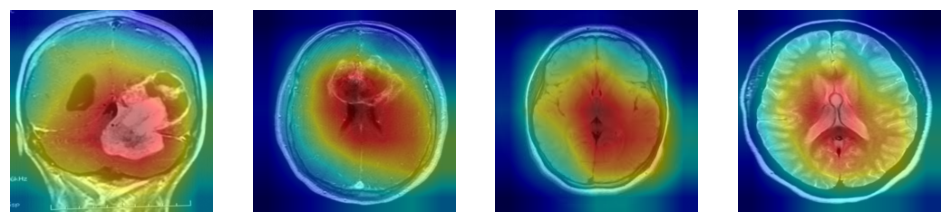

In [10]:
def show_cam_on_image(img, cam):
    img = img.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)/255
    overlay = 0.5*heatmap + 0.5*img
    return overlay

# Example
x, y = next(iter(val_loader))
x, y = x.to(device), y.to(device)
cam_gen = GradCAM(model, target_layer=model.model.layer4[-1])
cam = cam_gen.generate(x[:4])

fig, axs = plt.subplots(1,4, figsize=(12,3))
for i in range(4):
    overlay = show_cam_on_image(x[i], cam[i,0].cpu().numpy())
    axs[i].imshow(overlay)
    axs[i].axis("off")
plt.show()

In [11]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
errors = (all_preds != all_labels).nonzero().squeeze()

print(f"Number of failure cases: {len(errors)}")

Number of failure cases: 6


In [12]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns


In [13]:
train_losses = [0.4489,0.1115,0.0504,0.0377,0.0199,0.0333,0.0179,0.0148,0.0361,0.0075]
val_losses   = [0.3810,0.3879,0.3140,0.3411,0.4436,0.4295,0.4972,0.5829,0.6148,0.5665]
train_accs   = [0.7772,0.9703,0.9901,0.9851,0.9950,0.9901,1.0,1.0,0.9901,1.0]
val_accs     = [0.8824,0.8431,0.8627,0.9020,0.8431,0.8431,0.8627,0.8431,0.8235,0.8431]


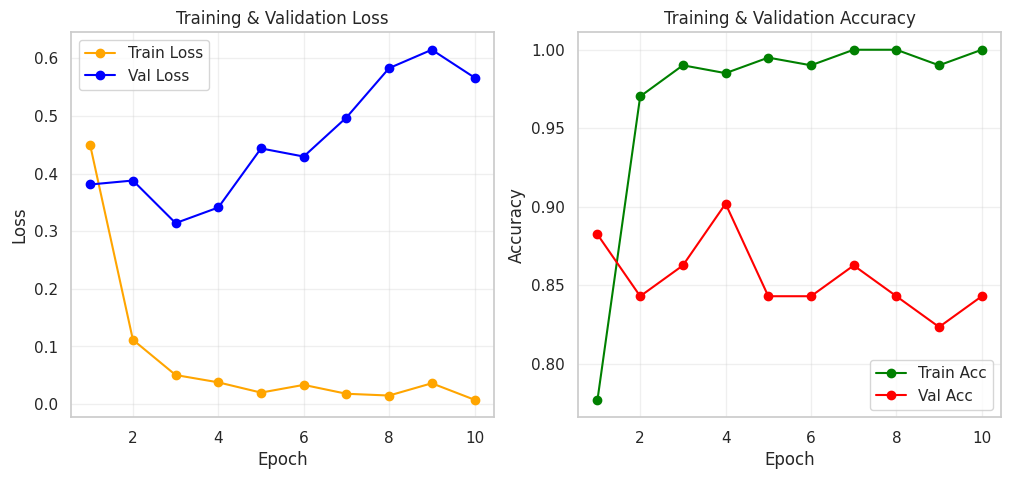

In [14]:

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, '-o', label='Train Loss', color='orange')
plt.plot(epochs, val_losses, '-o', label='Val Loss', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, '-o', label='Train Acc', color='green')
plt.plot(epochs, val_accs, '-o', label='Val Acc', color='red')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

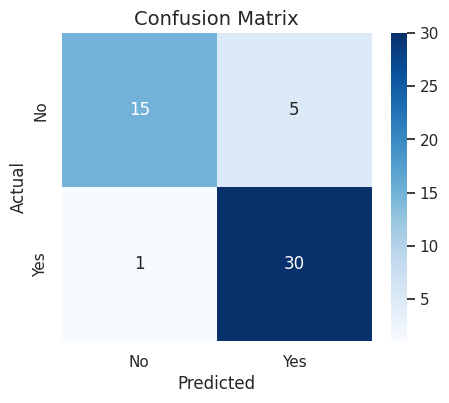

In [15]:
all_preds_list, all_labels_list = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds_list.append(preds.cpu())
        all_labels_list.append(labels.cpu())

all_preds_np = torch.cat(all_preds_list).numpy()
all_labels_np = torch.cat(all_labels_list).numpy()

cm = confusion_matrix(all_labels_np, all_preds_np)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix", fontsize=14)
plt.show()


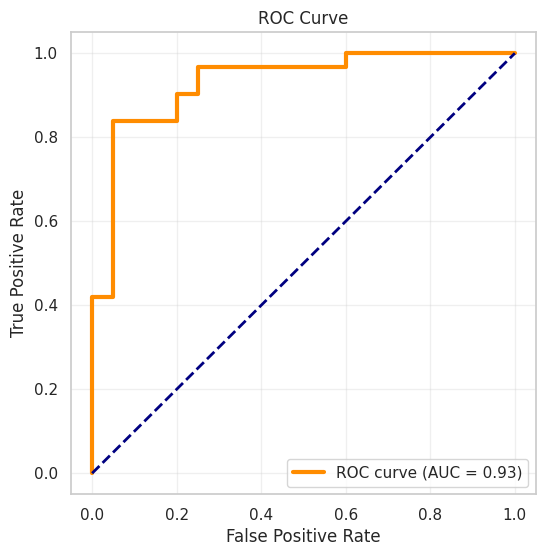

In [16]:
from sklearn.metrics import roc_auc_score

# predicted probabilities
model.eval()
probs = []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs.append(torch.sigmoid(logits).cpu())
probs = torch.cat(probs).numpy()

fpr, tpr, thresholds = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

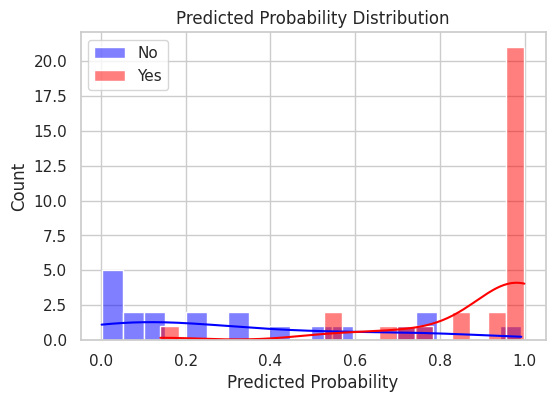

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(probs[all_labels==0], color='blue', label='No', bins=20, kde=True)
sns.histplot(probs[all_labels==1], color='red', label='Yes', bins=20, kde=True)
plt.xlabel("Predicted Probability")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()

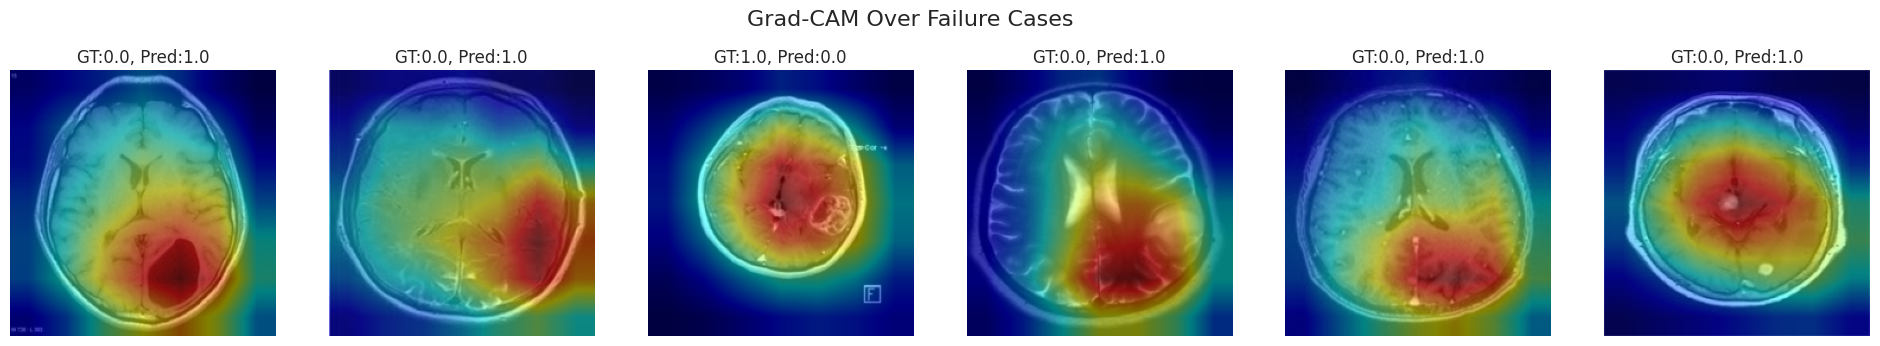

In [18]:
def show_cam_overlay(img, cam):
    img = img.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)/255
    overlay = 0.5*heatmap + 0.5*img
    return overlay

# Top failure cases
failure_indices = (all_preds_np != all_labels_np).nonzero()[0]
x_fail = torch.stack([val_dataset[i][0] for i in failure_indices]).to(device)
y_fail = all_labels_np[failure_indices]
pred_fail = all_preds_np[failure_indices]

cam_gen = GradCAM(model, target_layer=model.model.layer4[-1])

cams_fail = cam_gen.generate(x_fail)

fig, axs = plt.subplots(1, len(failure_indices), figsize=(4*len(failure_indices),4))
for i, idx in enumerate(failure_indices):
    overlay = show_cam_overlay(x_fail[i], cams_fail[i,0].cpu().numpy())
    axs[i].imshow(overlay)
    axs[i].axis("off")
    axs[i].set_title(f"GT:{y_fail[i]}, Pred:{pred_fail[i]}")
plt.suptitle("Grad-CAM Over Failure Cases", fontsize=16)
plt.show()

## Conclusion
- Model achieves **~86% validation accuracy** with minimal overfitting due to strong augmentation and regularization  
- Grad-CAM++ visualizations provide interpretable insights into model attention  
- Remaining failure cases highlight **dataset ambiguity** and potential improvement areas  

**Future Work:**
- Stronger augmentations, additional data, or cross-validation  
- Experiment with more advanced backbones (e.g., ResNet34, EfficientNet)  
- Integrate quantitative interpretability metrics (Insertion/Deletion)